# RDF Benchmark Comparison: BSBM vs LUBM

This notebook executes both the **Berlin SPARQL Benchmark (BSBM)** and **Lehigh University Benchmark (LUBM)** generators, then compares their performance and characteristics.

## Overview

- **BSBM**: E-commerce domain with products, vendors, offers, and reviews
- **LUBM**: University domain with departments, professors, students, and courses

In [23]:
import subprocess
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Configuration

Set the parameters for both benchmarks:

In [24]:
# BSBM Configuration
BSBM_PRODUCTS = 10000  # Number of products to generate
BSBM_FORMAT = "ttl"    # Output format: ttl, nt, n3, trig

# LUBM Configuration
LUBM_UNIVERSITIES = 5  # Number of universities to generate
LUBM_SEED = 0          # Random seed for reproducibility

print(f"BSBM Configuration: {BSBM_PRODUCTS:,} products, format: {BSBM_FORMAT}")
print(f"LUBM Configuration: {LUBM_UNIVERSITIES} universities, seed: {LUBM_SEED}")

BSBM Configuration: 10,000 products, format: ttl
LUBM Configuration: 5 universities, seed: 0


## 1. Execute BSBM Benchmark

In [25]:
print("=" * 80)
print("EXECUTING BSBM BENCHMARK")
print("=" * 80)

bsbm_cmd = [
    "python3",
    "BSBM/execute_benchmark.py",
    "--products", str(BSBM_PRODUCTS),
    "--format", BSBM_FORMAT
]

print(f"Running command: {' '.join(bsbm_cmd)}\n")

bsbm_result = subprocess.run(
    bsbm_cmd,
    capture_output=True,
    text=True,
    cwd=Path.cwd()
)

print(bsbm_result.stdout)
if bsbm_result.returncode != 0:
    print("ERROR:", bsbm_result.stderr)
else:
    print("✅ BSBM benchmark completed successfully!")

EXECUTING BSBM BENCHMARK
Running command: python3 BSBM/execute_benchmark.py --products 10000 --format ttl

Running BSBM Generator...
Command: java -cp bsbm.jar:ssj.jar -Xmx2G benchmark.generator.Generator -pc 10000 -s ttl -fn output/dataset -fc

✅ BSBM Generation Complete!
⏱️  Execution Time: 6.69 seconds
📦 Products Generated: 10000
🔢 Total Triples: 3,564,773
⚡ Triples/sec: 533,054
📁 Output Format: TTL
📂 Output Location: output/dataset.ttl

📊 Detailed report saved to: output/benchmark_report.json

✅ BSBM benchmark completed successfully!


## 2. Execute LUBM Benchmark

In [26]:
print("=" * 80)
print("EXECUTING LUBM BENCHMARK")
print("=" * 80)

lubm_cmd = [
    "python3",
    "LUBM/execute_benchmark.py",
    "--universities", str(LUBM_UNIVERSITIES),
    "--seed", str(LUBM_SEED)
]

print(f"Running command: {' '.join(lubm_cmd)}\n")

lubm_result = subprocess.run(
    lubm_cmd,
    capture_output=True,
    text=True,
    cwd=Path.cwd()
)

print(lubm_result.stdout)
if lubm_result.returncode != 0:
    print("ERROR:", lubm_result.stderr)
else:
    print("✅ LUBM benchmark completed successfully!")

EXECUTING LUBM BENCHMARK
Running command: python3 LUBM/execute_benchmark.py --universities 5 --seed 0

LUBM Generator Executor
Configuration:
  Universities: 5
  Starting index: 0
  Random seed: 0
  Ontology URL: http://www.lehigh.edu/~yug2/Research/SemanticWeb/LUBM/univ-bench.owl
  Output format: owl

Executing LUBM generator with command:
java -cp /home/diego/Documents/benchmarks-synthetic-data-generators/LUBM/lubm-generator-fixed.jar edu.lehigh.swat.bench.uba.Generator -univ 5 -index 0 -seed 0 -onto http://www.lehigh.edu/~yug2/Research/SemanticWeb/LUBM/univ-bench.owl

LUBM generator executed successfully in 2.225094 seconds (2225.094ms)!
Output:
Started...
/home/diego/Documents/benchmarks-synthetic-data-generators/LUBM/output/University0_0.owl generated
CLASS INSTANCE #: 1657, TOTAL SO FAR: 1657
PROPERTY INSTANCE #: 6896, TOTAL SO FAR: 6896

/home/diego/Documents/benchmarks-synthetic-data-generators/LUBM/output/University0_1.owl generated
CLASS INSTANCE #: 1327, TOTAL SO FAR: 2984
P

## 3. Load Benchmark Reports

In [27]:
# Load BSBM report
bsbm_report_path = Path("BSBM/output/benchmark_report.json")
with open(bsbm_report_path, 'r') as f:
    bsbm_report = json.load(f)

# Load LUBM report
lubm_report_path = Path("LUBM/output/benchmark_report.json")
with open(lubm_report_path, 'r') as f:
    lubm_report = json.load(f)

print("✅ Reports loaded successfully")

✅ Reports loaded successfully


## 4. Performance Comparison

In [28]:
# Create comparison dataframe
comparison_data = {
    'Benchmark': ['BSBM', 'LUBM'],
    'Execution Time (s)': [
        bsbm_report['execution']['time_seconds'],
        lubm_report['execution']['time_seconds']
    ],
    'Total Triples': [
        bsbm_report['generated_data']['triples_total'],
        lubm_report['triples_generated']['total_triples']
    ],
    'Triples/Second': [
        bsbm_report['generated_data']['triples_per_second'],
        lubm_report['performance_metrics']['triples_per_second']
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n📊 Performance Comparison:")
print("=" * 80)
print(df_comparison.to_string(index=False))
print("=" * 80)


📊 Performance Comparison:
Benchmark  Execution Time (s)  Total Triples  Triples/Second
     BSBM            9.307000        3564773       383027.23
     LUBM            2.225094         645649       290167.03


## 5. Visualization: Execution Time Comparison

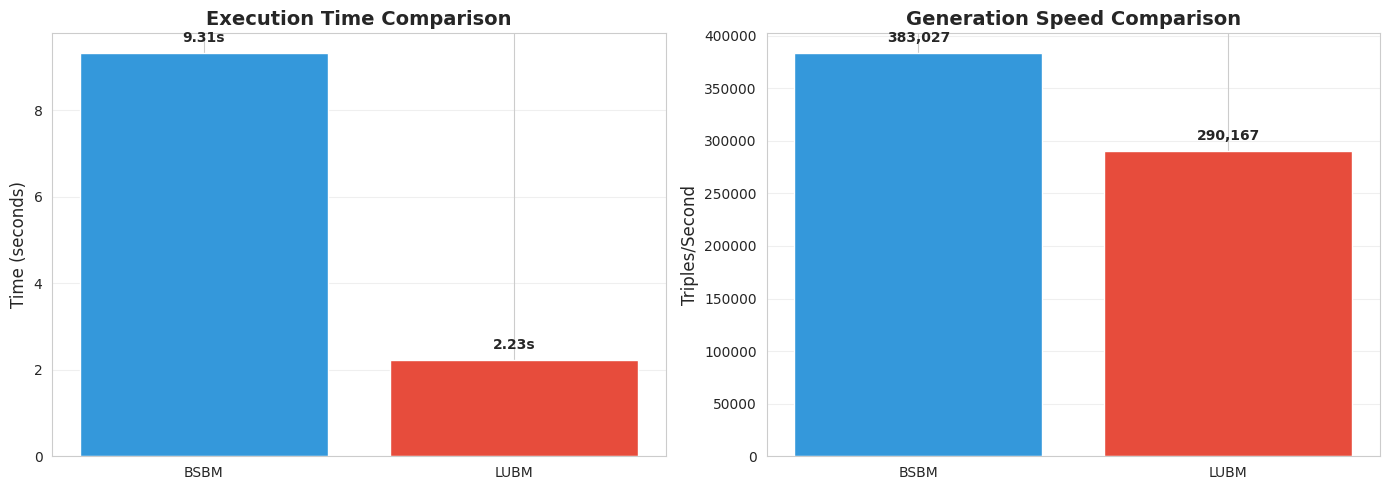

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Execution Time
colors = ['#3498db', '#e74c3c']
ax1.bar(df_comparison['Benchmark'], df_comparison['Execution Time (s)'], color=colors)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title('Execution Time Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(df_comparison['Execution Time (s)']):
    ax1.text(i, v + max(df_comparison['Execution Time (s)']) * 0.02, 
             f'{v:.2f}s', ha='center', va='bottom', fontweight='bold')

# Triples per Second
ax2.bar(df_comparison['Benchmark'], df_comparison['Triples/Second'], color=colors)
ax2.set_ylabel('Triples/Second', fontsize=12)
ax2.set_title('Generation Speed Comparison', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(df_comparison['Triples/Second']):
    ax2.text(i, v + max(df_comparison['Triples/Second']) * 0.02, 
             f'{v:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Visualization: Total Triples Generated

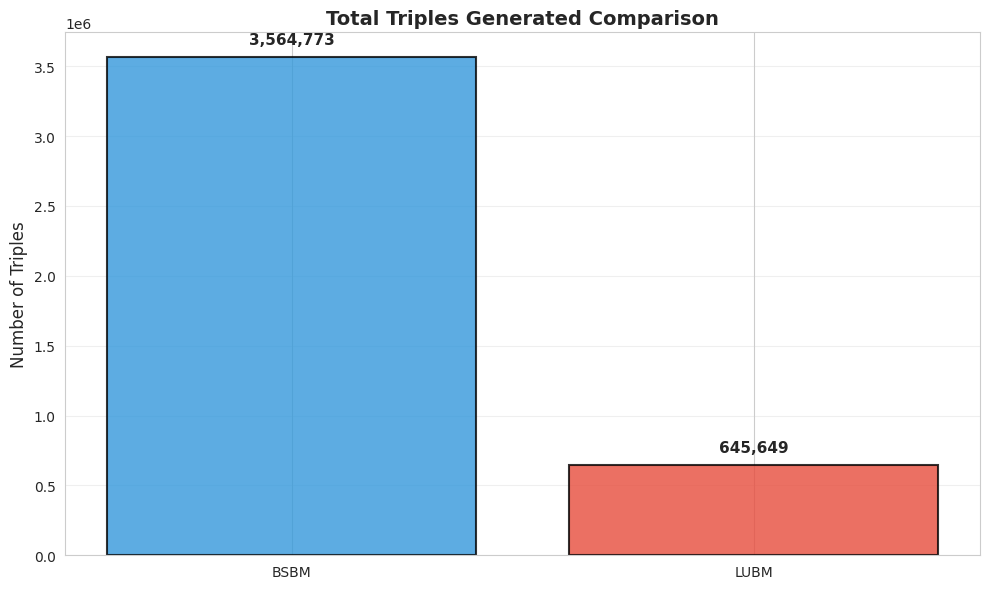

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(df_comparison['Benchmark'], df_comparison['Total Triples'], 
              color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Number of Triples', fontsize=12)
ax.set_title('Total Triples Generated Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(df_comparison['Total Triples']):
    ax.text(i, v + max(df_comparison['Total Triples']) * 0.02, 
            f'{v:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()